In [12]:
#1. find unique windspeed
import pandas as pd
df = pd.read_csv("Weather Data.csv")
print(df["Wind Speed_km/h"].unique())

[ 4  7  6  9 15 13 20 22 19 24 30 35 39 32 33 26 44 43 48 37 28 17 11  0
 83 70 57 46 41 52 50 63 54  2]


In [13]:
#2.FIND THE NO OF TIMES WHEN THE WEATHER IS EXACTLY CLEAR?
import pandas as pd
df = pd.read_csv("Weather Data.csv")
df.columns = df.columns.str.strip()
count = (df["Weather"] == "Clear").sum()
print("Number of times the weather is exactly 'Clear':", count)

Number of times the weather is exactly 'Clear': 1326


In [15]:
#3.FIND THE WINSPEED IS EXACTLY 4
df = pd.read_csv("Weather Data.csv")
result=df[df["Wind Speed_km/h"]==4]
print(result)

             Date/Time  Temp_C  Dew Point Temp_C  Rel Hum_%  Wind Speed_km/h  \
0     01-01-2012 00:00    -1.8              -3.9         86                4   
1     01-01-2012 01:00    -1.8              -3.7         87                4   
96    01-05-2012 00:00    -8.8             -11.7         79                4   
101   01-05-2012 05:00    -7.0              -9.5         82                4   
146   01-07-2012 02:00    -8.1             -11.1         79                4   
...                ...     ...               ...        ...              ...   
8768   12/31/2012 8:00    -8.6             -10.3         87                4   
8769   12/31/2012 9:00    -8.1              -9.6         89                4   
8770  12/31/2012 10:00    -7.4              -8.9         89                4   
8772  12/31/2012 12:00    -5.8              -7.5         88                4   
8773  12/31/2012 13:00    -4.6              -6.6         86                4   

      Visibility_km  Press_kPa       We

In [18]:
#4.FIND THE MEAN VISIBILITY
df = pd.read_csv("Weather Data.csv")
mean_visibility =df["Visibility_km"].mean()
print("Mean Visibility:",mean_visibility )


Mean Visibility: 27.664446721311478


In [20]:
5.#FIND THE STANDARD DEVIATION OF PRESSURE KPA
df = pd.read_csv("Weather Data.csv")
print((df["Press_kPa"]).std())

0.8440047459486474


In [21]:
#6.FIND ALL INSTANCES WHEN SNOW WAERE RECORDED
df = pd.read_csv("Weather Data.csv")
snow_count = df[df["Weather"].str.contains("Snow")].shape[0]
print(snow_count)

583


In [22]:
#7 SHOW ALL RECORDS WHEN WEATHER CONDITION IS FOG
snow_count = df[df["Weather"].str.contains("Fog")].shape[0]
print(snow_count)

426


In [23]:
#8 Find the mean of each numeric column for each weather condition
mean_by_weather = df.groupby("Weather").mean(numeric_only=True)

print(mean_by_weather)

                                            Temp_C  Dew Point Temp_C  \
Weather                                                                
Clear                                     6.825716          0.089367   
Cloudy                                    7.970544          2.375810   
Drizzle                                   7.353659          5.504878   
Drizzle,Fog                               8.067500          7.033750   
Drizzle,Ice Pellets,Fog                   0.400000         -0.700000   
Drizzle,Snow                              1.050000          0.150000   
Drizzle,Snow,Fog                          0.693333          0.120000   
Fog                                       4.303333          3.159333   
Freezing Drizzle                         -5.657143         -8.000000   
Freezing Drizzle,Fog                     -2.533333         -4.183333   
Freezing Drizzle,Haze                    -5.433333         -8.000000   
Freezing Drizzle,Snow                    -5.109091         -7.07

In [25]:
#9.Find records where Weather is 'Clear' OR Visibility is greater than 40 km
result = df[(df["Weather"] == "Clear") | (df["Visibility_km"] > 40)].shape[0]
print(result)

3027


In [26]:
#10. Find records where Weather is 'Clear' AND Relative Humidity is above 50%
result = df[(df["Weather"] == "Clear") & (df["Rel Hum_%"] > 50)].shape[0]
print(result)

1070


# Visualisation

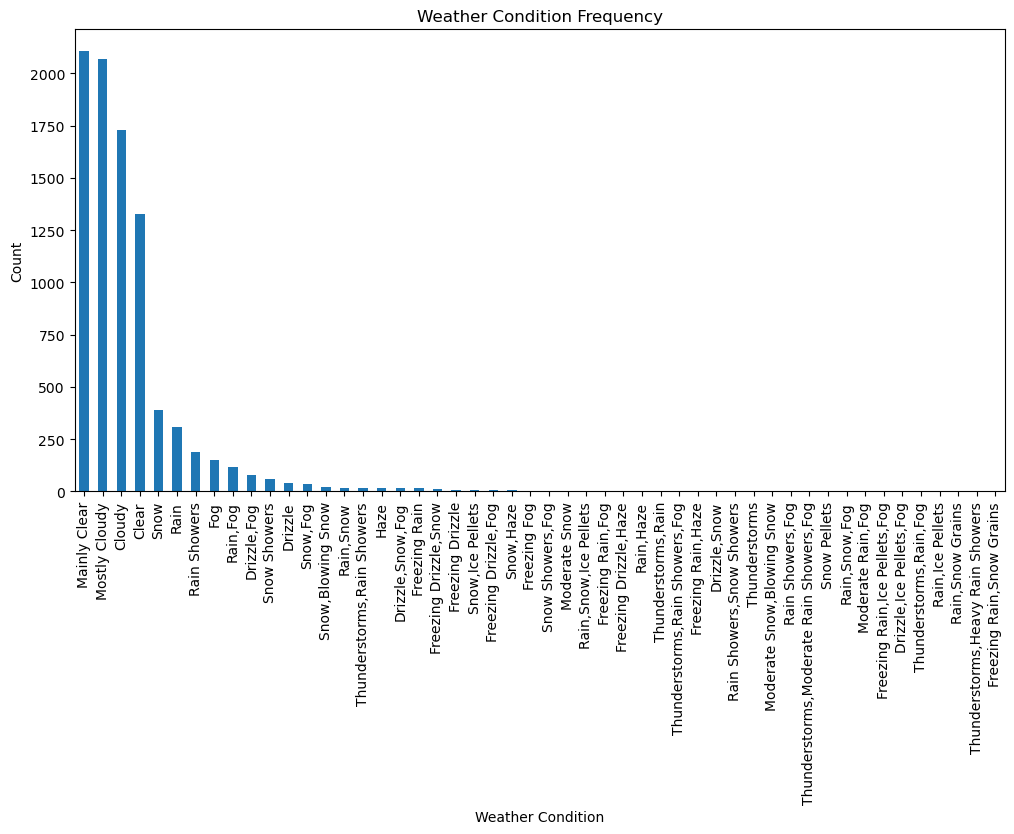

In [1]:
#1. Bar Chart (Weather Condition Count)
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Weather Data.csv")

weather_count = df["Weather"].value_counts()

plt.figure(figsize=(12,6))
weather_count.plot(kind="bar")
plt.title("Weather Condition Frequency")
plt.xlabel("Weather Condition")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

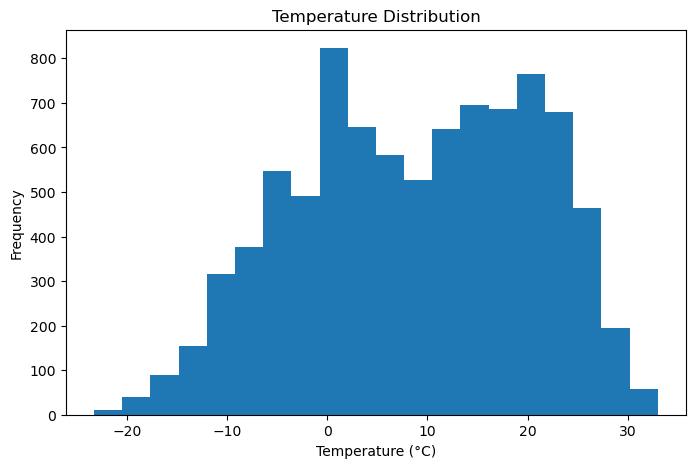

In [3]:
#2. Histogram (Temperature Distribution)
plt.figure(figsize=(8,5))
plt.hist(df["Temp_C"], bins=20)
plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.show()

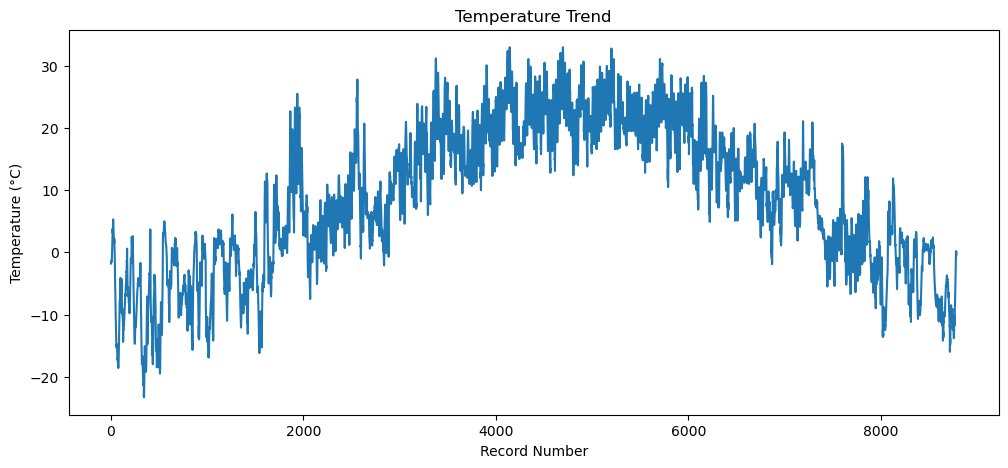

In [4]:
#3. Line Graph (Temperature Trend)
plt.figure(figsize=(12,5))
plt.plot(df["Temp_C"])
plt.title("Temperature Trend")
plt.xlabel("Record Number")
plt.ylabel("Temperature (°C)")
plt.show()

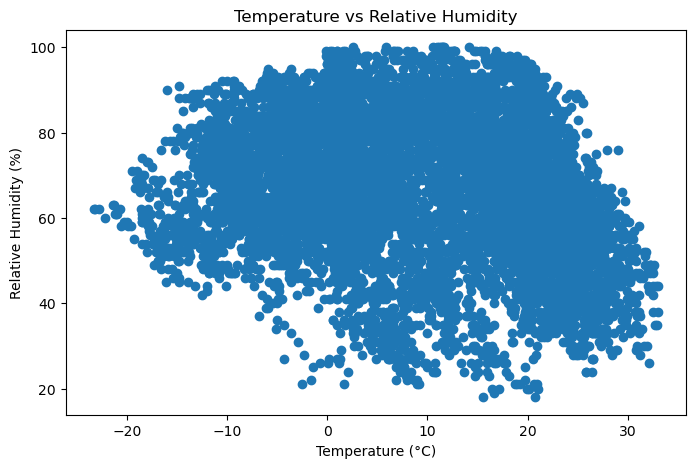

In [5]:
#4. Scatter Plot (Temperature vs Humidity)

#Shows the relationship between temperature and humidity.

plt.figure(figsize=(8,5))
plt.scatter(df["Temp_C"], df["Rel Hum_%"])
plt.title("Temperature vs Relative Humidity")
plt.xlabel("Temperature (°C)")
plt.ylabel("Relative Humidity (%)")
plt.show()

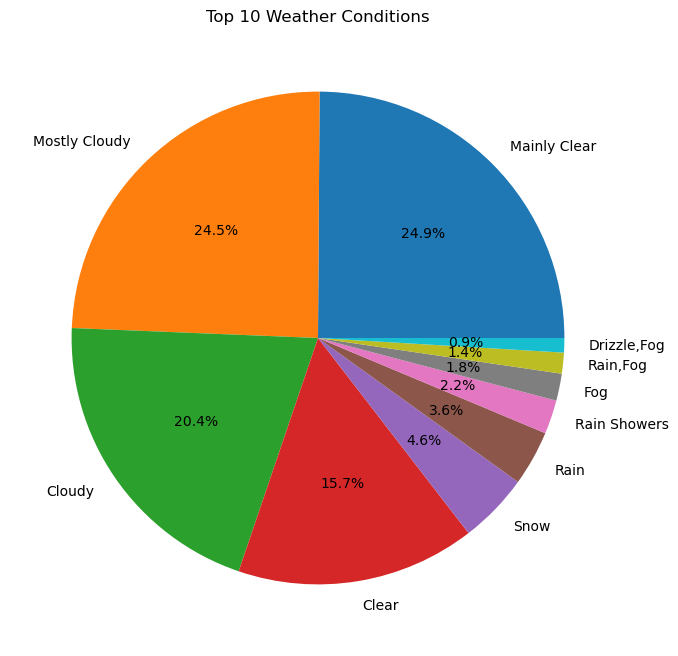

In [6]:
#5. Pie Chart (Weather Distribution)
weather = df["Weather"].value_counts().head(10)

plt.figure(figsize=(8,8))
plt.pie(weather, labels=weather.index, autopct="%1.1f%%")
plt.title("Top 10 Weather Conditions")
plt.show()

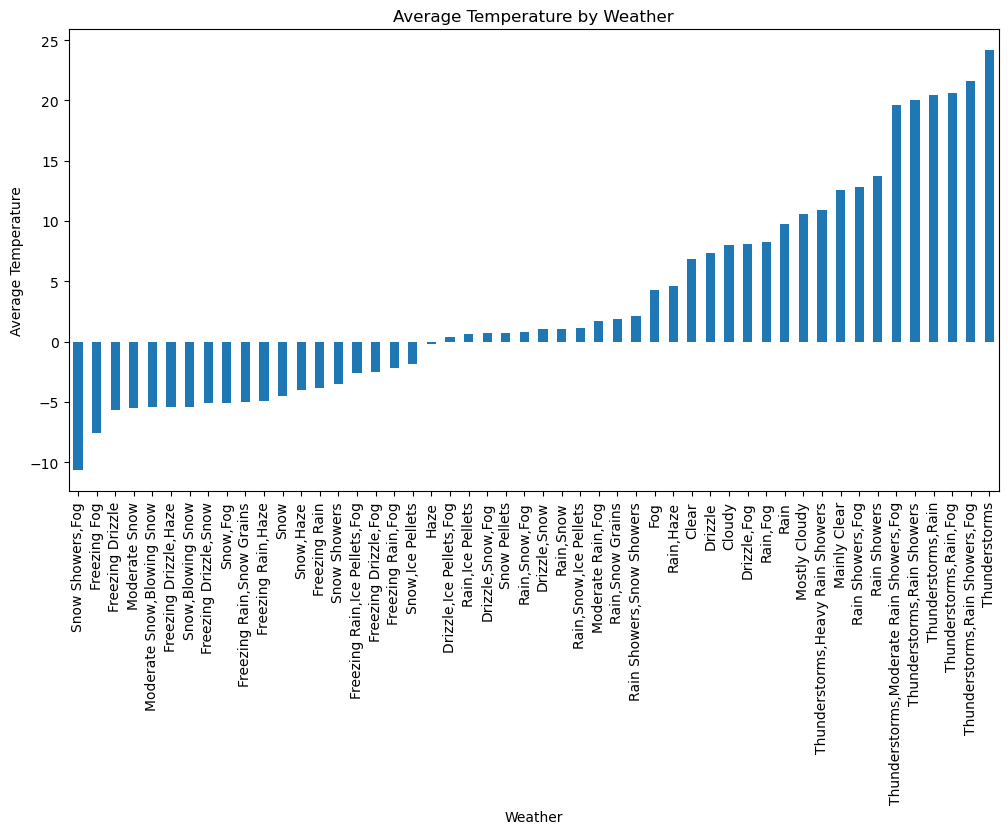

In [7]:
#6. Bar Chart (Average Temperature for Each Weather Condition)
avg_temp = df.groupby("Weather")["Temp_C"].mean().sort_values()

plt.figure(figsize=(12,6))
avg_temp.plot(kind="bar")
plt.title("Average Temperature by Weather")
plt.xlabel("Weather")
plt.ylabel("Average Temperature")
plt.xticks(rotation=90)
plt.show()

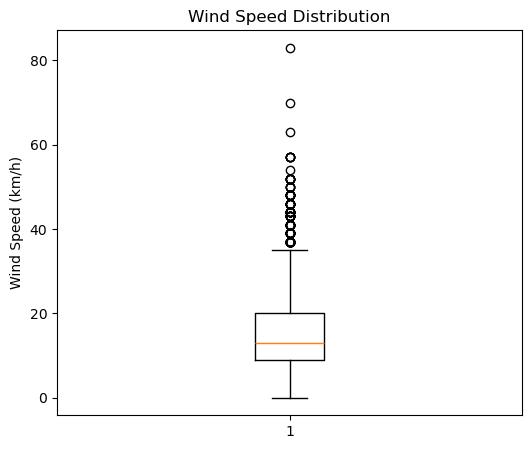

In [9]:
#7. Box Plot (Wind Speed)

#Shows the spread of wind speed values and outliers.

plt.figure(figsize=(6,5))
plt.boxplot(df["Wind Speed_km/h"])
plt.title("Wind Speed Distribution")
plt.ylabel("Wind Speed (km/h)")
plt.show()

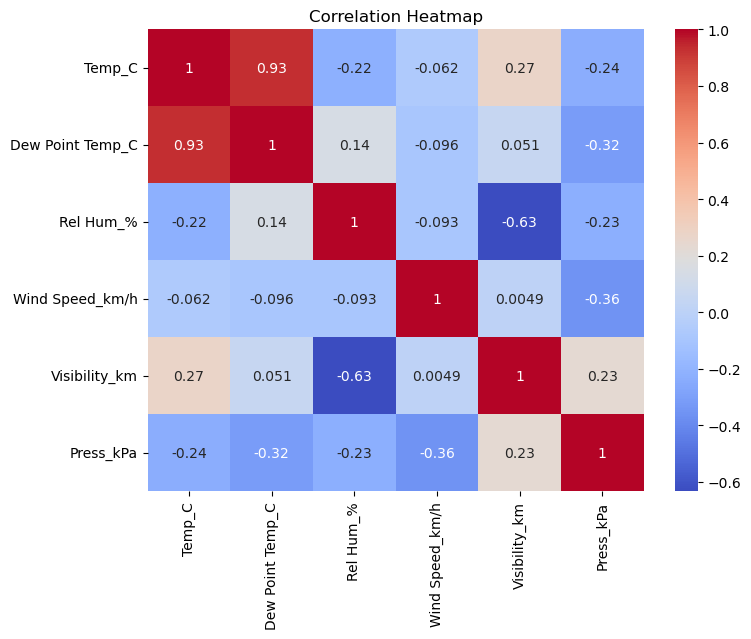

In [12]:
#8. Correlation Heatmap (Recommended)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    df[["Temp_C","Dew Point Temp_C","Rel Hum_%","Wind Speed_km/h","Visibility_km","Press_kPa"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()